


# Agentic AI for Optimized Graph Traversal of Delivery Vehicles Utilizing Gemini
### Bryan Milosevic-Hill
### April 2026

---



### **Preface**
I set out to author an all in one pipeline that passes context and variables to Gemini, which curates and responds with Prolog rules, and helps populate instance variables such as `batteryWh, maxPayloadKg, consumptionWhKm`. These rules are then used to simplify the graph of streets and adjust for weather conditions.


---
### **Features**
##### **Neighbourhood Drop Down**
I thought it would be interesting to have a [widget drop down](#Neighbourhood-Selector-Dropdown-/-Live-vs-Saved-Traffic-Alert) that allows the user to select which neighbourhood they would like to focus on. The rest of the code blocks execute with this decision in mind. This selection then filters the entire CSV down to only data points relevant to the selected neighbourhood. This drastically improves program efficiency, all while allowing the flexibility to choose which neighbourhood of focus.

<p align="center"><img src="https://i.imgur.com/OmWvm1k.png" width="40%"></p>

##### **Live vs Stored Toggle** 
In the same cell as the drop down, I added a toggle which mutates a global variable. This variable changes which version of the KB Gemini function is called. I did this to streamline testing, and to provide consistent **street data** to Gemini every run, regardless of day. Doing this allowed me to debug and correctly attribute errors to those in my program and not via hallucination.


##### **Algorithmic Graph Simplification** 


I also initially had intentions to extend this assignment to include my interest in quantum computing, and wanted to use this as a demonstration of [Grover's Algorithm](https://en.wikipedia.org/wiki/Grover%27s_algorithm). Anticipating that, I wrote my own set of [Prolog rules](#Prolog-Rules-to-Simplify-Graph) to simplify the graph. This simplification works by linearly scanning all edges. Should an edge have a degree of 2, it would be erased, a new connection would be made between its predecessor and successor, and the weights would be summed. Simplifying the graph for a quantum workflow is vital as `fewer nodes = fewer qubits`, since to run Grover's we need to encode the search space into a superposition.

<p align="center"><img src="https://i.imgur.com/RxDmTSO.png" width="30%"></p>

##### **Parsing CSV and GEOJSON programmatically**
I decided to [parse the CSV on my own](#Data-Ingest-&-Graph-Parsing). For this I loaded the CSV data and with the GEOJSON library, pandas, and geopandas, I extracted neighbourhood names to populate a drop down widget. I used those same names to fragment the graph to only focus on nodes in that geographic region.

---

#### **Prompting Gemini**
This was my first time interfacing with an AI inline with code. There was quite a learning curve but after reading through Google's documentation I was able to get the hang of it. After the initial learning curve, I found prompting Gemini in line to be intuitive and easy. Links like this made my life so much easier. ```https://ai.google.dev/gemini-api/docs/document-processing```

##### **KB Generation** 
Prompting was more of a hassle than I first expected. On my very first run of [`PDF Reading and Variable Extraction`](#PDF-Reading-and-Variable-Extraction), I used a whopping 146513 tokens in total. One can assume I was hitting my usage limits readily and quickly.. too quickly. I then decided to change how Gemini would write the knowledge base, and appended its returned code with my programmatically generated list of atoms [`Gemini Rules`](#Gemini-Authored-Prolog-Rules-and-Atoms).  This allowed me to pass the list of atoms to Gemini as syntactical context without it regurgitating them back in its response. This drastically lowered the total tokens used during my [KB calls](#Gemini-Authored-Prolog-Rules-and-Atoms).

#### **Results**
<img src="https://i.imgur.com/hXscKJA.png" align="right" width="30%" style="margin-left: 15px; margin-bottom: 10px;">


After running all 3 [search algorithms](#Graph-Search-Algorithms), some things become quickly apparent. BFS prioritizes the smallest number of nodes, and minimizes the number of transits between these nodes. Had the graph not been weighted, BFS perhaps could have been a viable strategy though as you can see BFS consumed **62.01** Wh over **3.44** km compared to UCS's **54.18** Wh over **3.01** km. I found this to be a consistent pattern as UCS was the best choice among the 3 in every trial I ran. UCS expanded fewer nodes than BFS (**433** vs **451**), while still finding a longer path in terms of moves (**32** vs **26**). UCS explores fewer nodes overall because the priority queue lets it skip expensive branches early, but the path it returns has more stops as it is optimizing for cost, not transit count. This feature of UCS alone makes it the obvious choice for routing when battery is the constraint we are minimizing for.

DFS was the clear loser, which is to be expected as DFS is not best suited for problems like shortest path routing on weighted graphs. By the nature of DFS, if the first path it explores to completion is unlucky, it can end up spending a long time searching through poor paths that move far away from the destination. This results, on average, with longer paths and more battery usage. In this specific example DFS’ path was **13**km, costing a whopping **244.24**Wh.  That amount of usage is over four times the energy consumption of UCS for the same start and end point. DFS did expand the fewest nodes (340) which makes it the runtime winner, but in a use case such as route planning, that win is misleading at best, and horribly inefficient at worst.

In my implementation, `notPassable` edges are [removed before the search runs](#Applying-Geminis-KB), so all three algorithms avoid closures by default. However, if `notPassable` roads were treated as high cost edges instead of being fully removed, BFS would still be willing to route through them because it is cost-blind and only cares about hop count. UCS, on the other hand, would see the inflated cost and route around them.

<img src="https://i.imgur.com/U6ZzQfd.png" width="60%" style="display: block; margin: 10px auto;">

There is not much to say about our [constraint problem](#Scheduling), as I did not intend to compare the runtime of different scheduling algorithms until after implementing Grovers. Here you can see that along with the Gemini-produced atoms, we were able to assign package deliveries to time slots. This is where I had planned on looking at speedups from Grover's, as I wanted to use this as an opportunity to practice and learn about quantum information, but time did not permit.

<img src="https://i.imgur.com/EeALGcF.png" width="60%" style="display: block; margin: 10px auto;">

**Window 2:** $30.0 + 40.0 + 20.0 = 90.0 \text{ kg} < 125 \text{ kg}$  and $23.59 + 16.71 + 27.70 = 68.0 \text{ Wh} < 672 \text{ Wh}$ 

**Window 3:** $45.5 + 55.0 + 15.0 = 115.5 \text{ kg} < 125 \text{ kg}$  and $34.57 + 78.95 + 68.41 = 181.93 \text{ Wh} < 672 \text{ Wh}$ 
<div style="clear: both;"></div>

However, the process was not straightforward. I encountered several challenges while working with Gemini and had to make changes to resolve them.




#### **Hallucination Report**
From execution to execution even on simple tasks, the instance variables Gemini would provide me would fluctuate. What’s cool about using Gemini is that this program becomes pretty modular. I could swap the bike manual for another competitor’s bike, or even an electric car manual, and with only slight tweaks to the prompting the same pipeline could still return useful and nuanced results. That is the real value of using an LLM here, the whole pipeline becomes modular. Gemini would also close streets that were not closed or streets that did not even exist. To mitigate this I set a limit on the amount of rules it could write in hopes that it could focus on few quality rules, runtime consistency would greatly benefit.


##### **KB Consistency** 
At first, graph disconnects were rampant. I learned that to receive a more usable response from Gemini, you had to be strict with your prompting, and specify specific return conditions. I ended up writing a [schema](#Gemini-Authored-Prolog-Rules-and-Atoms) for it that worked pretty well.

```"calculate_cost(NodeA, NodeB, PayloadKg, CostWh) notPassable(NodeA, NodeB) pruned_edge_info(PrunedList) battery_capacity_wh(Value) max_payload_kg(Value) consumption_wh_per_km(Value) === PYSWIP COMPATIBILITY === - All street name atoms must be single-quoted: 'broadway', 'fieldston_rd' - Negation uses \\+ not 'not' - No module declarations - File will be loaded AFTER graph.txt via consult/1, so edge/4 is already available. Do NOT include edge/4 facts. All helper predicates you create must only reference streets from the .txt file. Singleton variables are forbidden — use _ for unused variables. Ensure that no graph disconnection occurs."```

#### **Future Work**

I still would very much like to use this dataset as an opportunity to explore the advantages that scheduling problems gain in a quantum regime. I plan on continuing this project after the semester is over to do just that. If I had to do it all over, I would look for a alternative to PYSWIP for stability and other quality of life reasons. I would often have to **restart my kernel** between Prolog code block executions, storing variables in .txt files and reading them after. I had to do this as the Prolog atom instance would not reset between cells execution, and atoms from previous runs would accumulate and ruin the knowledge base.

---

### Imports and Populating Gemini API Key from .env

In [1]:
from dotenv import load_dotenv
import os
from google import genai
from google.genai import types
from google.genai.types import Tool, GenerateContentConfig
import json
import pathlib

load_dotenv()
api_key = os.getenv("GEMINI")
client = genai.Client(api_key=os.getenv("GEMINI"))

### Neighbourhood Selector Dropdown / Live vs Saved Traffic Alert

In [2]:
## this will be the neighbourhood selector
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import geopandas as gpd
from shapely import wkt
import numpy as np
import matplotlib as plt
from pyswip import Prolog
import pathlib

nta = gpd.read_file("resources/graph geo data/Resources/2020tabu.geojson")
df = pd.read_csv("resources/graph geo data/Resources/Centerline_20260329.csv")

streets = nta["ntaname"].tolist()
strees = streets.sort()


neighbourhoodSelect = widgets.Dropdown(
    options=streets,
    value = "Riverdale-Spuyten Duyvil",
    description='Choose:'
)


trafficSelect = widgets.ToggleButtons(
    options=['Live', 'Stored Html'],
    description='NYC Traffic Advisory:',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltips=['Live Data, Gemini reads from the page', 'Stored HTML in resources for consistent testing'],
#     icons=['check'] * 3
)


selected = "Riverdale-Spuyten Duyvil"


def read(change):
    global selected
    selected = change['new']
    print("Selected:", selected)

neighbourhoodSelect.observe(read, names='value')

trafficLive = True 
def traffic_read(change):
    global trafficLive
    trafficLive = (change['new'] == 'Live')
    print("Live traffic:", trafficLive)

trafficSelect.observe(traffic_read, names='value')

display(neighbourhoodSelect)
display(trafficSelect)
#print(nta["ntaname"])

Dropdown(description='Choose:', index=197, options=('Allerton', 'Alley Pond Park', "Annadale-Huguenot-Prince's…

ToggleButtons(description='NYC Traffic Advisory:', options=('Live', 'Stored Html'), tooltips=('Live Data, Gemi…

In [3]:
# pip install, pandas, 

print(selected)

Riverdale-Spuyten Duyvil


# Data Ingest & Graph Parsing

(122266, 65)
(960, 81)


Text(0.5, 1.0, 'Riverdale-Spuyten Duyvil')

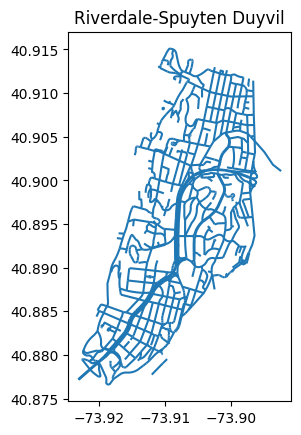

In [4]:
#https://networkx.org/documentation/stable/auto_examples/geospatial/plot_lines.html

neighbourhood = selected

df["geometry"] = df["the_geom"].apply(wkt.loads)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
print(gdf.shape)   
neighborhood = nta[nta["ntaname"] == neighbourhood]
gdfFiltered = gpd.sjoin(gdf, neighborhood, how="inner", predicate="intersects")
print(gdfFiltered.shape) 
#print(gdfFiltered.columns.tolist())

show = gdfFiltered.plot();
show.set_title(neighbourhood)


## Computational Graph Simplification
<img src="https://i.imgur.com/9z85ECL.png" width="50%">


In [5]:
from pyswip import Prolog
prolog = Prolog()
#gdfFiltered
edges = []
for _, row in gdfFiltered.iterrows():
    geom = row.geometry
    name = row["Full Street Name"]
    if geom.geom_type == "MultiLineString":
        for line in geom.geoms:
            coords = list(line.coords)
            edges.append((name,coords[0], coords[-1], line.length))
    else:
        coords = list(geom.coords)
        edges.append((name,coords[0], coords[-1], geom.length))
print(len(edges))


1221


# Prolog Rules to Simplify Graph 

In [6]:
from pyswip import Prolog
prolog = Prolog()


node_to_street = {}
seen = set()
for name, start, end, weight in edges:
    s = (round(start[0], 4), round(start[1], 4))
    e = (round(end[0], 4), round(end[1], 4))
    sa = ("n_%s_%s" % (s[0], s[1])).replace("-","m").replace(".","d")
    ea = ("n_%s_%s" % (e[0], e[1])).replace("-","m").replace(".","d")
    safe_name = name.lower().replace(" ","_").replace("'","").replace("-","_")
    node_to_street[sa] = safe_name
    node_to_street[ea] = safe_name
    key = (sa, ea)
    if (key not in seen):
        seen.add(key)
        prolog.assertz("edge(%s, %s, %s, '%s')" % (sa, ea, weight, safe_name))

print("Unique edges asserted: %d" % len(seen))


nodes = set()
for sa, ea in seen:
    nodes.add(sa)
    nodes.add(ea)

count_dist = {}
for node in nodes:
    as_start = len(list(prolog.query("edge(%s, _, _, _)" % node)))
    as_end = len(list(prolog.query("edge(_, %s, _, _)" % node)))
    total = as_start + as_end
    count_dist[total] = count_dist.get(total, 0) + 1

print("Connection count distribution:")
for k in sorted(count_dist.keys()):
    print("  %d connections: %d nodes" % (k, count_dist[k]))


prolog.assertz("countB(X,W,Adr) :- findall(W1,edge(X,_,W1,_),Wf), findall(K,edge(_,X,K,_),Wb), append(Wf,Wb,W), findall(I,edge(X,I,_,_),Ef), findall(O,edge(O,X,_,_),Eb), append(Ef,Eb,Adr)")

prolog.assertz("simplify(A,B,C,Names) :- edge(A,_,_,_), countB(A,RW,RA), length(RA,Value), Value = 2, B = RW, C = RA, findall(N,edge(A,_,_,N),N1), findall(N,edge(_,A,_,N),N2), append(N1,N2,Names), retractall(edge(A,_,_,_)), retractall(edge(_,A,_,_)), nth0(0,C,X0), nth0(1,C,X1), sum_list(B,L), assertz(edge(X0,X1,L,merged))")


collapsed_log = []
nuked = []
while True:
    results = list(prolog.query("simplify(A, B, C, Names)"))
    if not results:
        break
    for r in results:
        node = str(r['A'])
        neighbors = [str(x) for x in r['C']]
        weights = [float(x) for x in r['B']]
        streets = [str(x) for x in r['Names']]
        collapsed_log.append((node, neighbors[0], neighbors[1], sum(weights)))
        nuked.append((node_to_street.get(node, "unknown"),
            streets[0] if len(streets) > 0 else "unknown",
            weights[0],
            streets[1] if len(streets) > 1 else "unknown",
            weights[1]))

print("Collapsed %d nodes total" % len(collapsed_log))
print("Nuked edges: %d" % len(nuked))
for n in nuked[:5]:
    print("  %s | %s (%.4f) <-> %s (%.4f)" % n)

remaining = list(prolog.query("edge(X,Y,W,Name)"))
print("Edges after: %d" % len(remaining))
for r in remaining[:5]:
    print("  %s -> %s  w=%s  street=%s" % (r['X'], r['Y'], r['W'], r['Name']))

import networkx as nx

G = nx.Graph()
for r in remaining:
    G.add_edge(r['X'], r['Y'])

print("Connected:", nx.is_connected(G))
print("Components:", nx.number_connected_components(G))

Unique edges asserted: 1209
Connection count distribution:
  1 connections: 111 nodes
  2 connections: 322 nodes
  3 connections: 310 nodes
  4 connections: 147 nodes
  5 connections: 16 nodes
  6 connections: 6 nodes
  7 connections: 3 nodes
  8 connections: 1 nodes
Collapsed 317 nodes total
Nuked edges: 317
  vinmont_rd | w__254_st (0.0006) <-> vinmont_rd (0.0012)
  henry_hudson_pkwy | henry_hudson_pkwy (0.0007) <-> henry_hudson_pkwy (0.0007)
  w__249_st | w__249_st (0.0005) <-> w__249_st (0.0005)
  johnson_ave | johnson_ave (0.0002) <-> johnson_ave (0.0002)
  johnson_ave | johnson_ave (0.0003) <-> merged (0.0004)
Edges after: 892
  n_m73d9153_40d8802 -> n_m73d9138_40d8815  w=0.002092332381709577  street=arlington_ave
  n_m73d9016_40d9051 -> n_m73d9012_40d9069  w=0.0017774808923188517  street=tyndall_ave
  n_m73d911_40d8821 -> n_m73d9109_40d8824  w=0.0003099285923629808  street=johnson_ave
  n_m73d9109_40d8879 -> n_m73d9102_40d8884  w=0.0007859146991390623  street=henry_hudson_pkwy_e

In [7]:
largest = max(nx.connected_components(G), key=len)

main_edges = [r for r in remaining if r['X'] in largest and r['Y'] in largest]

for r in main_edges[:5]:
    print("edge(%s, %s, %s, '%s')." % (r['X'], r['Y'], r['W'], r['Name']))

with open("resources/graph geo data/graph.txt", "w") as f:
    for r in main_edges:
        f.write("edge(%s, %s, %s, '%s').\n" % (r['X'], r['Y'], r['W'], r['Name']))

print("Wrote %d edges to graph.txt (main component only)" % len(main_edges))

G2 = nx.Graph()
for r in main_edges:
    G2.add_edge(r['X'], r['Y'])

print("Connected:", nx.is_connected(G2))
print("Components:", nx.number_connected_components(G2))

edge(n_m73d9153_40d8802, n_m73d9138_40d8815, 0.002092332381709577, 'arlington_ave').
edge(n_m73d9016_40d9051, n_m73d9012_40d9069, 0.0017774808923188517, 'tyndall_ave').
edge(n_m73d911_40d8821, n_m73d9109_40d8824, 0.0003099285923629808, 'johnson_ave').
edge(n_m73d9109_40d8879, n_m73d9102_40d8884, 0.0007859146991390623, 'henry_hudson_pkwy_e').
edge(n_m73d9071_40d9045, n_m73d9071_40d9052, 0.0007134684773457921, 'arlington_ave').
Wrote 879 edges to graph.txt (main component only)
Connected: True
Components: 1


# Gemenini Calls 

### PDF Reading and Variable Extraction

In [8]:
from google import genai
from google.genai import types
from google.genai.types import Tool, GenerateContentConfig

import json


#https://ai.google.dev/gemini-api/docs/document-processing

client = genai.Client(api_key=os.getenv("GEMINI"))

# Retrieve and encode the PDF byte
filepath = pathlib.Path('resources/graph geo data/Resources/RadCity 5Plus Manual.pdf')

prompt = "Read through the Bike PDF provided and store the battery specs in WH, the maximum payload of the bike, the consumption rate in Wh/KM and any considerations one needs to make when planning a trip, these considerations should be a max of 55 words, and expect urban travel in Down town newyork. Speak also about how one can optimize range in Clear, rainy, and snowy/icy conditions. Explain *conservative* estimates on modified consumption rates to these conditions"


schema = {
    "type": "object",
    "properties": {
        "batteryWh": {"type": "number"},
        "maxPayloadKg": {"type": "number"},
        "consumptionWhKm": {"type": "number"},
        "considerations": {"type": "string"}
    },
    "required": ["batteryWh", "maxPayloadKg", "consumptionWhKm"]
}


response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[
        types.Part.from_bytes(
            data=filepath.read_bytes(),
            mime_type='application/pdf',
        ),
        prompt],
    config={
        "response_mime_type": "application/json",
        "response_json_schema": schema
    }
)


returned = json.loads(response.text)

batteryWh = returned["batteryWh"]
maxPayloadKg = returned["maxPayloadKg"]
consumptionWhKm = returned["consumptionWhKm"]
note = returned["considerations"]

print(batteryWh, maxPayloadKg, consumptionWhKm)
print(note)

with open("resources/graph geo data/bike_specs.txt", "w") as f:
    json.dump(returned, f)
print("Saved to bike_specs.txt")

672 125 9.33
For NYC travel, optimize range by using low PAS and pedaling from stops. In rain, brake early and avoid deep puddles. In snow, expect range loss from cold; keep battery indoors. Conservative estimates: 9.3Wh/km (clear), 14Wh/km (rain), 20Wh/km (snow). Ensure ambient temperatures stay above -15°C for safety.
Saved to bike_specs.txt


#### Reload Bike Context

In [8]:

with open("resources/graph geo data/bike_specs.txt", "r") as f:
    specs = json.load(f)
batteryWh = specs["batteryWh"]
maxPayloadKg = specs["maxPayloadKg"]
consumptionWhKm = specs["consumptionWhKm"]
note = specs["considerations"]

print(batteryWh, maxPayloadKg, consumptionWhKm)
print(note)

672 125 9.33
For NYC travel, optimize range by using low PAS and pedaling from stops. In rain, brake early and avoid deep puddles. In snow, expect range loss from cold; keep battery indoors. Conservative estimates: 9.3Wh/km (clear), 14Wh/km (rain), 20Wh/km (snow). Ensure ambient temperatures stay above -15°C for safety.


# Gemini Authored Prolog Rules and Atoms

In [9]:
#https://ai.google.dev/gemini-api/docs/url-context
model_id = "gemini-3-flash-preview"

graphForGem = pathlib.Path('resources/graph geo data/graph.txt')

editedPrompt = "Assume mildly frosty conditions with -5 degrees C, frost, and ice. No active snow or rain. From the source's information create a Prolog knowledge base that structures the following information: Inputted Edges (list), Bike constraints (Update based off recommendations given wrt weather), and the traffic advisory information. Include atoms for Max Payload of the bike: %s , BatteryWh: %s , consumption Rate WhKm: %s (to get in Wh/degree multiply by 111.32 to match units of atoms) , and weather adjustments based off of these considerations '%s'. We are working in the %s district of newyork today" % (maxPayloadKg,batteryWh,consumptionWhKm,note,neighbourhood)
editedPrompt = editedPrompt + " \n Return ONLY the exact pr code as the EXACT response with no adjustments will be saved as a .pr file. The file will be executed via the PYSWIP library. You have also been given a .txt file that has all the current atoms, this is so should a rule be needed that targets one of the street names listed you know how to interface with it.  ** YOU SHOULD NOT INCLUDE THESE ATOMS IN YOUR RETURNED CODE. I need Query rules that calculate cost of bike travel (WHICH FACTORS IN THE PARAM ABOVE Usage, weather, distance), notPassable (so if a street is closed and this returns true routing diverts) This should function so I can run all of my atoms on this code, and the graph is updated accordingly for cost, closures and anything else you deem necessary. Return 3 or 4 quality rules, and any rules with updated traffic advisory so when I pass in all the atoms the graph is adjusted. Should a node be deleted somehow, a list should be populated of the name of the pruned edge and its closest non pruned neighbour. Do not meander or explain code but feel free to justify any decisions with inline comments. Be liberal with token usage. \n === PREDICATE SCHEMA (use exactly these names and arities) === \n  calculate_cost(NodeA, NodeB, PayloadKg, CostWh) notPassable(NodeA, NodeB) pruned_edge_info(PrunedList) battery_capacity_wh(Value) max_payload_kg(Value) consumption_wh_per_km(Value) === PYSWIP COMPATIBILITY === - All street name atoms must be single-quoted: 'broadway', 'fieldston_rd' - Negation uses \\+ not 'not' - No module declarations - File will be loaded AFTER graph.txt via consult/1, so edge/4 is already available. Do NOT include edge/4 facts. All helper predicates you create must only reference streets from the .txt file. Singleton variables are forbidden — use _ for unused variables. Ensure that no graph disconnection occurs. !!!ENSURE THAT AFTER ALL ATOMS FROM .TXT ARE RUN ON IT, THE GRAPH REMAINS CONNECTED, AS WE WILL BE RUNNING SEARCH ALGO ON THEM. \n \n=== CRITICAL CONNECTIVITY RULE ===\nYou must NOT close more than FIVE street name via is_restricted/notPassable. Closing multiple streets (e.g. broadway AND henry_hudson_pkwy) WILL disconnect the graph and crash the search algorithms. Pick up to 5 impactful closures from the advisory and leave everything else open. Ensure the graph will live please. consumption_wh_per_km(R) must also be an atom"
tools = [
  {"url_context": {}},
]



weekDay = "https://www.nyc.gov/html/dot/html/motorist/weektraf.shtml"
weekEnd = "https://www.nyc.gov/html/dot/html/motorist/wkndtraf.shtml"

if (trafficLive == True):
    
    prompt = "Read the NYC traffic Advisory, if its a weekend go to the %s link and weekday go to %s ." % (weekEnd, weekDay) + editedPrompt
    response = client.models.generate_content(
        model=model_id,
        contents=[
            types.Part.from_bytes(
                data=graphForGem.read_bytes(),
                mime_type='text/plain',
            ),
            prompt
        ],
        config=GenerateContentConfig(
            tools=tools,
            max_output_tokens=88536,
            thinking_config=types.ThinkingConfig(thinking_budget=7117),
        )
    )
    

if (trafficLive == False):
    filepath = pathlib.Path('resources/graph geo data/Resources/NYCApr7.html')
    prompt = "Read the NYC Traffic advisory from file 'NYCApr7.HTML' " + editedPrompt

    response = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=[
            types.Part.from_bytes(
                data=filepath.read_bytes(),
                mime_type='text/html',
            ),
            types.Part.from_bytes(
                data=graphForGem.read_bytes(),
                mime_type='text/plain',
            ),
            prompt],
    )

for each in response.candidates[0].content.parts:
    print(each.text)
print("Input tokens:", response.usage_metadata.prompt_token_count)
print("Output tokens:", response.usage_metadata.candidates_token_count)
print("Total tokens:", response.usage_metadata.total_token_count)

prolog_code = "".join(part.text for part in response.candidates[0].content.parts)
prolog_code = prolog_code.replace("```prolog", "").replace("```", "").strip()

with open("resources/graph geo data/knowledgeBase.pl", "w") as f:
    f.write(prolog_code)

print("Saved to knowledgeBase.pl")

battery_capacity_wh(672).
max_payload_kg(125).
consumption_wh_per_km(11.5).

% Traffic Advisory & Weather Restrictions (Limit 5 to ensure connectivity)
% 1. Broadway: Restricted due to Broadway Bridge pothole repairs and sidewalk maintenance.
% 2. W 262nd St: Closed for construction involving concrete pumps and boom trucks.
% 3. Pedestrian and Bike Path Link: Closed due to severe frost and ice accumulation on steel spans.
% 4. Edgehill Ave: Restricted safety hazard due to -5C ice on steep inclines.
% 5. Edsall Ave: Restricted due to utility work and icy conditions near the industrial rail corridor.
is_restricted('broadway').
is_restricted('w__262_st').
is_restricted('pedestrian_and_bike_path_link').
is_restricted('edgehill_ave').
is_restricted('edsall_ave').

% calculate_cost(NodeA, NodeB, PayloadKg, CostWh)
% Calculates energy consumption based on distance (degrees to km), weather-adjusted base rate, and payload impact.
% Base rate 11.5 Wh/km accounts for -5C temperature and reduced b

# Applying Geminis KB

In [1]:

## this consolidates text of atoms with rules gem wrote

from pyswip import Prolog
prolog = Prolog()

rules = open("resources/graph geo data/knowledgeBase.pl").read()
rules = rules.replace(", S)", ", _)")
with open("resources/graph geo data/knowledgeBase.pl", "w") as f:
    f.write(rules)

with open("resources/graph geo data/knowledge_base.pl", "w") as f:
    f.write(":- dynamic edge/4.\n\n")
    f.write(open("resources/graph geo data/graph.txt").read())
    f.write("\n\n")
    f.write(open("resources/graph geo data/knowledgeBase.pl").read())

prolog.consult("resources/graph geo data/knowledge_base.pl")
from pyswip import Prolog
prolog = Prolog()
prolog.consult("resources/graph geo data/knowledge_base.pl")

# Test it
print(list(prolog.query("calculate_cost(n_m73d8971_40d9001, n_m73d897_40d9002, 50, Cost)")))
print(list(prolog.query("notPassable(X, Y)")))


[{'Cost': 0.19450467571082344}, {'Cost': 3.3266833743382147}]
[{'X': 'n_m73d9121_40d8811', 'Y': 'n_m73d9116_40d8823'}, {'X': 'n_m73d8971_40d9001', 'Y': 'n_m73d897_40d9002'}, {'X': 'n_m73d9214_40d8784', 'Y': 'n_m73d9214_40d8783'}, {'X': 'n_m73d9215_40d8783', 'Y': 'n_m73d9214_40d8784'}, {'X': 'n_m73d9203_40d8791', 'Y': 'n_m73d9203_40d8791'}, {'X': 'n_m73d897_40d9003', 'Y': 'n_m73d897_40d9006'}, {'X': 'n_m73d8973_40d8917', 'Y': 'n_m73d8967_40d8958'}, {'X': 'n_m73d9232_40d8772', 'Y': 'n_m73d9216_40d8782'}, {'X': 'n_m73d8978_40d8907', 'Y': 'n_m73d8973_40d8917'}, {'X': 'n_m73d897_40d8979', 'Y': 'n_m73d8971_40d8986'}, {'X': 'n_m73d9214_40d8784', 'Y': 'n_m73d9203_40d8791'}, {'X': 'n_m73d9203_40d879', 'Y': 'n_m73d92_40d8787'}, {'X': 'n_m73d9201_40d8792', 'Y': 'n_m73d9184_40d8805'}, {'X': 'n_m73d9139_40d8795', 'Y': 'n_m73d9137_40d8804'}, {'X': 'n_m73d8979_40d8906', 'Y': 'n_m73d8978_40d8907'}, {'X': 'n_m73d8966_40d9102', 'Y': 'n_m73d8976_40d9103'}, {'X': 'n_m73d92_40d8787', 'Y': 'n_m73d92_40d8775

In [2]:
import networkx as nx
# this makes it a graph and checks if its connected 
blocked = set((r['X'], r['Y']) for r in prolog.query("notPassable(X, Y)"))
all_edges = list(prolog.query("edge(X, Y, W, S)"))

G = nx.Graph()
for e in all_edges:
    if (e['X'], e['Y']) not in blocked and (e['Y'], e['X']) not in blocked:
        G.add_edge(e['X'], e['Y'], weight=float(e['W']), street=str(e['S']))

print("Connected:", nx.is_connected(G))
print("Components:", nx.number_connected_components(G))

Connected: True
Components: 1


## Gemini Routes and Scheduling Instance Variables

In [57]:


filepath = pathlib.Path('knowledge_base.pl')

prompt = "Read through the PL I gave you which is a connected graph. Pick 2 pairs of Start point and Destination an return the streetname fields as variables to me. In the label field call it something like 'Trip to grocery store on *streetname*' or 'Optimal route to hospital on 'streetname' from 'streetname'. (Make locations not too close geographically, minimum 500m away) Then create a package deilvery itenerary. 6 packages all with different weights, time window, and return them for a scheduling problem (Make sure its possible with  %d kg max payload and 3 windows, but making scheduling not trivial.). These packages should also have delivery destinations and then give a nuanced start location. Ensure streets you choose are listed explicitly as an edge" % (maxPayloadKg)


schema = {
    "type": "object",
    "properties": {
        "tripPairs": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "label": {"type": "string"},
                    "startStreet": {"type": "string"},
                    "destinationStreet": {"type": "string"}
                },
                "required": ["label", "startStreet", "destinationStreet"]
            },
            "minItems": 2,
            "maxItems": 2
        },
        "deliveryStartLocation": {
            "type": "string"
        },
        "packages": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "packageId": {"type": "string"},
                    "weightKg": {"type": "number"},
                    "timeWindow": {"type": "string", "enum": ["window1", "window2", "window3"]},
                    "destinationStreet": {"type": "string"}
                },
                "required": ["packageId", "weightKg", "timeWindow", "destinationStreet"]
            },
            "minItems": 6,
            "maxItems": 6
        }
    }
}


response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[
        types.Part.from_bytes(
            data=filepath.read_bytes(),
            mime_type='text/plain',
        ),
        prompt],
    config={
        "response_mime_type": "application/json",
        "response_json_schema": schema
    }
)


returned = json.loads(response.text)

tripPairs = returned["tripPairs"]
deliveryStart = returned["deliveryStartLocation"]
packages = returned["packages"]

for t in tripPairs:
    print("%s: %s → %s" % (t["label"], t["startStreet"], t["destinationStreet"]))

print("Delivery hub:", deliveryStart)

for p in packages:
    print("  %s: %skg, %s → %s" % (p["packageId"], p["weightKg"], p["timeWindow"], p["destinationStreet"]))



Optimal route to hospital on palisade_ave from arlington_ave: arlington_ave → palisade_ave
Trip to grocery store on broadway from riverdale_ave: riverdale_ave → broadway
Delivery hub: kappock_st
  PKG-A01: 45.5kg, window1 → delafield_ave
  PKG-A02: 55.0kg, window1 → independence_ave
  PKG-B01: 30.0kg, window2 → henry_hudson_pkwy_e
  PKG-B02: 40.0kg, window2 → netherland_ave
  PKG-C01: 15.0kg, window3 → fieldston_rd
  PKG-C02: 20.0kg, window3 → oxford_ave


# Graph Search Algorithms 

Optimal route to hospital on palisade_ave from arlington_ave: n_m73d9153_40d8802 → n_m73d9201_40d8792
Trip to grocery store on broadway from riverdale_ave: n_m73d9109_40d8804 → n_m73d8971_40d9001
[('n_m73d9153_40d8802', 'n_m73d9138_40d8815', {'weight': 0.002092332381709577, 'street': 'arlington_ave'}), ('n_m73d9153_40d8802', 'n_m73d9163_40d8808', {'weight': 0.00114313756036691, 'street': 'w__227_st'}), ('n_m73d9153_40d8802', 'n_m73d9161_40d8795', {'weight': 0.0010067453756282775, 'street': 'arlington_ave'})]
BFS: 26 hops, 451 nodes expanded
DFS: 110 hops, 340 nodes expanded
UCS: 32 hops, 433 nodes expanded, 0.0270 cost (deg)
UCS energy: 54.18 Wh


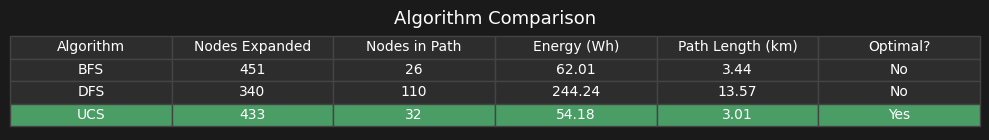

In [83]:

def street_to_node(street):
    result = list(prolog.query("edge(X, _, _, '%s')" % street))
    return result[0]['X'] if result else None

for t in tripPairs:
    t['startNode'] = street_to_node(t['startStreet'])
    t['endNode'] = street_to_node(t['destinationStreet'])
    print("%s: %s → %s" % (t['label'], t['startNode'], t['endNode']))


print(list(G.edges(data=True))[:3])

from collections import deque

def bfs(G, start, end):
    queue = deque([start])
    visited = {start}
    came_from = {start: None}
    nodes_expanded = 0

    while queue:
        current = queue.popleft()
        nodes_expanded += 1
        if current == end:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], nodes_expanded
        for neighbor in G[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                came_from[neighbor] = current
                queue.append(neighbor)
    return None, nodes_expanded


def dfs(G, start, end):
    stack = [start]
    visited = {start}
    came_from = {start: None}
    nodes_expanded = 0

    while stack:
        current = stack.pop()
        nodes_expanded += 1
        if current == end:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], nodes_expanded
        for neighbor in G[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                came_from[neighbor] = current
                stack.append(neighbor)
    return None, nodes_expanded


import heapq

def ucs(G, start, end):
    heap = [(0, start)]
    visited = set()
    came_from = {start: None}
    cost_so_far = {start: 0}
    nodes_expanded = 0

    while heap:
        current_cost, current = heapq.heappop(heap)
        if current in visited:
            continue
        visited.add(current)
        nodes_expanded += 1
        if current == end:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], nodes_expanded, current_cost
        for neighbor, data in G[current].items():
            new_cost = current_cost + data['weight']
            if neighbor not in visited and (neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]):
                cost_so_far[neighbor] = new_cost
                came_from[neighbor] = current
                heapq.heappush(heap, (new_cost, neighbor))
    return None, nodes_expanded, float('inf')


start = street_to_node(tripPairs[1]['startStreet'])
end = street_to_node(tripPairs[1]['destinationStreet'])

bfs_path, bfs_expanded = bfs(G, start, end)
dfs_path, dfs_expanded = dfs(G, start, end)
ucs_path, ucs_expanded, ucs_cost = ucs(G, start, end)

print("BFS: %d hops, %d nodes expanded" % (len(bfs_path), bfs_expanded))
print("DFS: %d hops, %d nodes expanded" % (len(dfs_path), dfs_expanded))
print("UCS: %d hops, %d nodes expanded, %.4f cost (deg)" % (len(ucs_path), ucs_expanded, ucs_cost))
rate = list(prolog.query("consumption_wh_per_km(R)"))[0]['R']
print("UCS energy: %.2f Wh" % (ucs_cost * 111.32 * rate))


def path_distance_deg(G, path):
    return sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

bfs_dist = path_distance_deg(G, bfs_path)
dfs_dist = path_distance_deg(G, dfs_path)
ucs_dist = ucs_cost


#table -----


fig, ax = plt.subplots(figsize=(10, 1.5))
fig.patch.set_facecolor('#1a1a1a')
ax.set_title("Algorithm Comparison", color='white', fontsize=13)
ax.axis('off')

colLabels = ["Algorithm", "Nodes Expanded", "Nodes in Path", "Energy (Wh)", "Path Length (km)", "Optimal?"]
rows = []
for name, expanded, dist, path in [("BFS", bfs_expanded, bfs_dist, bfs_path), ("DFS", dfs_expanded, dfs_dist, dfs_path), ("UCS", ucs_expanded, ucs_dist, ucs_path)]:
    energy = dist * 111.32 * rate
    km = dist * 111.32
    optimal = "Yes" if name == "UCS" else "No"
    rows.append([name, "%d" % expanded, "%d" % len(path), "%.2f" % energy, "%.2f" % km, optimal])

table = ax.table(cellText=rows, colLabels=colLabels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#2d2d2d')
    if row > 0 and rows[row - 1][5] == "Yes":
        cell.set_facecolor("#4a9d65")
[cell.set_edgecolor('#444444') for cell in table.get_celld().values()]
[cell.set_text_props(color='white') for cell in table.get_celld().values()]
plt.tight_layout()
plt.show()

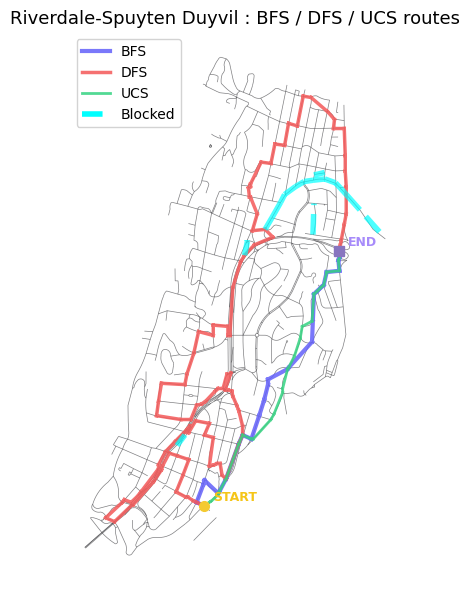

In [80]:
import matplotlib.pyplot as plt

def node_xy(G, n):
    parts = str(n).lstrip('n_').split('_')
    def decode(s):
        return float(s.replace('m', '-').replace('d', '.'))
    return decode(parts[0]), decode(parts[1])

def draw_path(ax, G, path, color, lw, label):
    if not path:
        return
    xs, ys = [], []
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        geom = G[u][v].get('geometry')
        if geom:
            for x, y in geom.coords:
                xs.append(x); ys.append(y)
            xs.append(None); ys.append(None)
        else:
            x0, y0 = node_xy(G, u)
            x1, y1 = node_xy(G, v)
            xs += [x0, x1, None]
            ys += [y0, y1, None]
    ax.plot(xs, ys, color=color, linewidth=lw, alpha=0.85, label=label)

fig, ax = plt.subplots(figsize=(6, 6))
gdfFiltered.plot(ax=ax, color='#2a2a2e', linewidth=0.5, alpha=0.6)

for path, color, label, lw in [
    (bfs_path, "#6360FA", 'BFS', 3.0),
    (dfs_path,  "#F45858", 'DFS', 2.5),
    (ucs_path,  "#34D381", 'UCS', 2.0),
]:
    draw_path(ax, G, path, color, lw, label)

# blocked edges dashed on top
for u, v in blocked:
    geom = G[u][v].get('geometry') if G.has_edge(u, v) else None
    if geom:
        xs, ys = zip(*geom.coords)
        ax.plot(xs, ys, color='cyan', linewidth=4, alpha=0.7, zorder=7, linestyle='--')
    else:
        x0, y0 = node_xy(G, u)
        x1, y1 = node_xy(G, v)
        ax.plot([x0, x1], [y0, y1], color='cyan', linewidth=4, alpha=0.7, zorder=7, linestyle='--')

sx, sy = node_xy(G, start)
ex, ey = node_xy(G, end)
ax.plot(sx, sy, 'o', color="#F4CA30", markersize=7, zorder=8)
ax.plot(ex, ey, 's', color="#8875BF", markersize=7, zorder=8)
ax.annotate('START', (sx, sy), xytext=(6,4), textcoords='offset points', color='#F5C518', fontsize=9, fontweight='bold')
ax.annotate('END',   (ex, ey), xytext=(6,4), textcoords='offset points', color='#A78BFA', fontsize=9, fontweight='bold')

ax.plot([], [], color='cyan', linewidth=4, linestyle='--', label='Blocked')
ax.legend(loc='upper left', framealpha=0.85)
ax.set_title(f"{neighbourhood} : BFS / DFS / UCS routes", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [60]:
for name, path in [('BFS', bfs_path), ('DFS', dfs_path), ('UCS', ucs_path)]:
    violations = [(path[i], path[i+1]) for i in range(len(path)-1)
                  if (path[i], path[i+1]) in blocked or (path[i+1], path[i]) in blocked]
    print(f"{name}: {len(violations)} blocked edges used")

BFS: 0 blocked edges used
DFS: 0 blocked edges used
UCS: 0 blocked edges used


# Scheduling

In [61]:
from constraint import Problem

hubNode = street_to_node(deliveryStart)
if hubNode is None or hubNode not in G:
    hubNode = list(G.nodes())[0]
    print("Hub not in graph, using fallback: %s" % hubNode)

rate = list(prolog.query("consumption_wh_per_km(R)"))[0]['R']

cspPackages = packages[:6]
for p in cspPackages:
    destNode = street_to_node(p['destinationStreet'])
    if destNode is None or destNode not in G:
        print("SKIP %s — %s not in graph" % (p['packageId'], p['destinationStreet']))
        p['energyWh'] = 0
        continue
    _, _, costDeg = ucs(G, hubNode, destNode)
    p['energyWh'] = costDeg * 111.32 * rate
    print("%s: %.2f Wh, %.1f kg" % (p['packageId'], p['energyWh'], p['weightKg']))

windows = ["window1", "window2", "window3"]
pkgIds = [p['packageId'] for p in cspPackages]

problem = Problem()
for pid in pkgIds:
    problem.addVariable(pid, windows)

def weightOk(*assignments):
    for w in windows:
        total = sum(cspPackages[i]['weightKg'] for i in range(len(assignments)) if assignments[i] == w)
        if total >= maxPayloadKg:
            return False
    return True

def energyOk(*assignments):
    for w in windows:
        total = sum(cspPackages[i]['energyWh'] for i in range(len(assignments)) if assignments[i] == w)
        if total >= batteryWh:
            return False
    return True

def temporalOk(*assignments):
    for i, w in enumerate(assignments):
        dest = street_to_node(cspPackages[i]['destinationStreet'])
        if dest is None or dest not in G:
            return False
    return True

problem.addConstraint(weightOk, pkgIds)
problem.addConstraint(energyOk, pkgIds)
problem.addConstraint(temporalOk, pkgIds)

solutions = problem.getSolutions()
print("\n%d valid schedules" % len(solutions))

if solutions:
    best = solutions[0]
    print("\nSchedule:")
    for p in cspPackages:
        print("  %s (%.1f kg, %.2f Wh) -> %s" % (p['packageId'], p['weightKg'], p['energyWh'], best[p['packageId']]))
    for w in windows:
        wt = sum(p['weightKg'] for p in cspPackages if best[p['packageId']] == w)
        en = sum(p['energyWh'] for p in cspPackages if best[p['packageId']] == w)
        print("  %s: %.1f/%s kg, %.1f/%s Wh — %s" % (w, wt, maxPayloadKg, en, batteryWh, "PASS" if wt < maxPayloadKg and en < batteryWh else "FAIL"))

PKG-A01: 34.57 Wh, 45.5 kg
PKG-A02: 78.95 Wh, 55.0 kg
PKG-B01: 23.59 Wh, 30.0 kg
PKG-B02: 16.71 Wh, 40.0 kg
PKG-C01: 68.41 Wh, 15.0 kg
PKG-C02: 27.70 Wh, 20.0 kg

486 valid schedules

Schedule:
  PKG-A01 (45.5 kg, 34.57 Wh) -> window3
  PKG-A02 (55.0 kg, 78.95 Wh) -> window3
  PKG-B01 (30.0 kg, 23.59 Wh) -> window2
  PKG-B02 (40.0 kg, 16.71 Wh) -> window2
  PKG-C01 (15.0 kg, 68.41 Wh) -> window3
  PKG-C02 (20.0 kg, 27.70 Wh) -> window2
  window1: 0.0/125 kg, 0.0/672 Wh — PASS
  window2: 90.0/125 kg, 68.0/672 Wh — PASS
  window3: 115.5/125 kg, 181.9/672 Wh — PASS


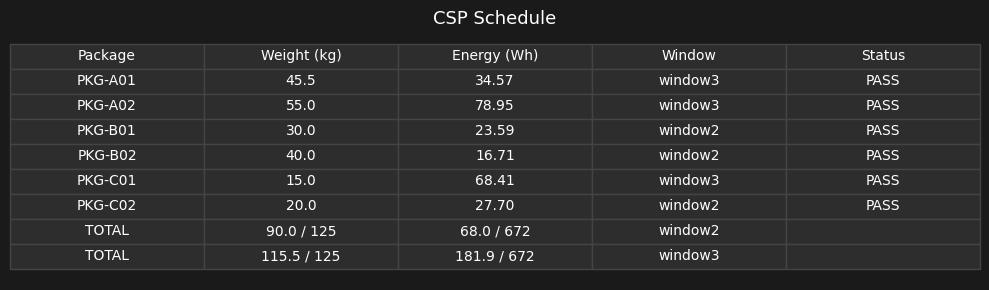

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
fig.patch.set_facecolor('#1a1a1a')



ax.set_title("CSP Schedule", color='white', fontsize=13)
ax.axis('off')

colLabels = ["Package", "Weight (kg)", "Energy (Wh)", "Window", "Status"]
rows = []
for p in cspPackages:
    w = best[p['packageId']]
    rows.append([p['packageId'], "%.1f" % p['weightKg'], "%.2f" % p['energyWh'], w, "PASS"])

for w in windows:
    wt = sum(p['weightKg'] for p in cspPackages if best[p['packageId']] == w)
    en = sum(p['energyWh'] for p in cspPackages if best[p['packageId']] == w)
    if wt > 0 or en > 0:
        rows.append(["TOTAL", "%.1f / %s" % (wt, maxPayloadKg), "%.1f / %s" % (en, batteryWh), w, ""])

table = ax.table(cellText=rows, colLabels=colLabels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
[cell.set_facecolor('#2d2d2d') for cell in table.get_celld().values()]
[cell.set_edgecolor('#444444') for cell in table.get_celld().values()]
[cell.set_text_props(color='white') for cell in table.get_celld().values()]


plt.tight_layout()
plt.show()